Q1: Top 5 Most Common Restaurant Types:
rest_type
Quick Bites       6573
Casual Dining     5158
Cafe              1391
Dessert Parlor    1031
Delivery          1004
Name: count, dtype: int64

Q2: Average Rating: Table Booking vs No Table Booking:
book_table
No     3.636891
Yes    4.172665
Name: rate, dtype: float64

Q3: Top 5 Restaurant Types by Average Cost for Two:
rest_type
Fine Dining     2783.898305
Club            2155.000000
Lounge          1748.815166
Microbrewery    1639.823009
Bar             1334.269663
Name: approx_cost(for two people), dtype: float64

Q4: Top 5 Most Voted Restaurants (Customer Engagement):
                              name  votes  rate
49170  Byg Brewski Brewing Company  16832   4.9
3921   Byg Brewski Brewing Company  16345   4.9
18643                         Toit  14956   4.7
36668                     Truffles  14726   4.7
33913                     Truffles  14723   4.7

Q5: Correlation Matrix (Votes, Rating, Cost):
                                votes 

/tmp/ipykernel_58/1421276690.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='book_table', y='rate', palette='Set2')


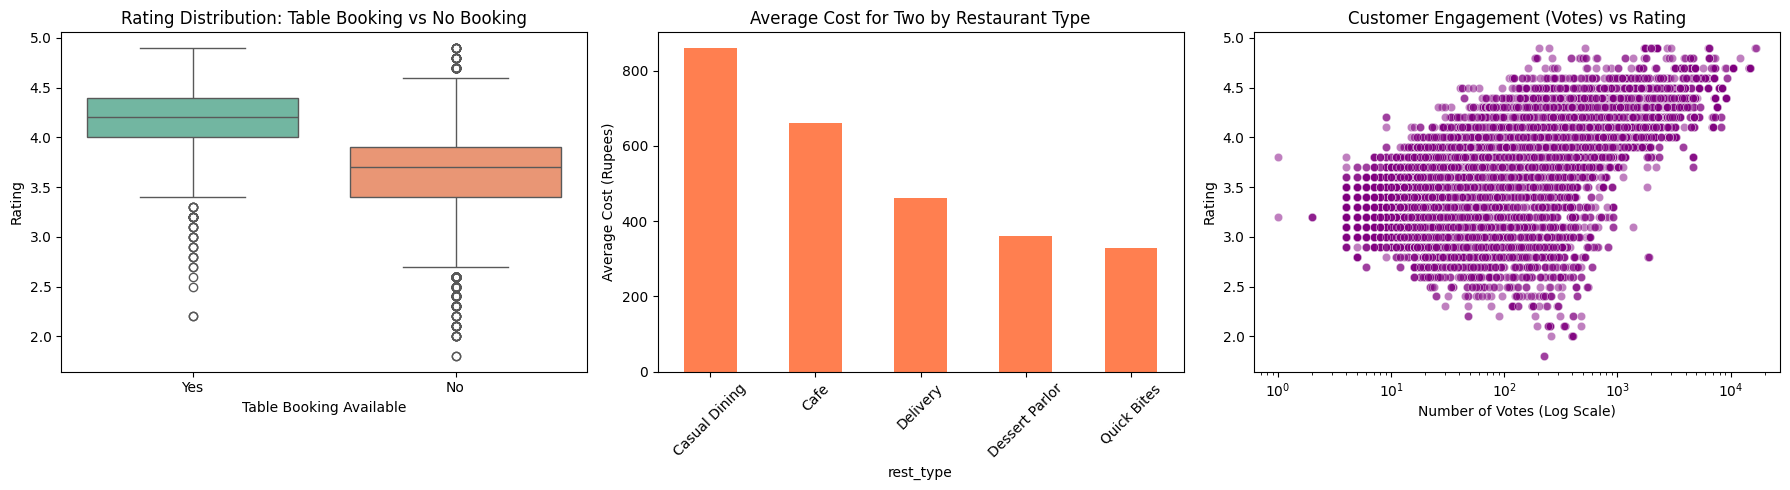

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/thoufii/zomatodts/zomato.csv')

cols_to_keep = ['name', 'rate', 'votes', 'rest_type', 'approx_cost(for two people)', 'book_table']
df = df[cols_to_keep]
df = df.dropna()
df = df.drop_duplicates()

df['rate'] = df['rate'].astype(str).apply(lambda x: x.split('/')[0].strip() if '/' in x else None)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
df = df.dropna(subset=['rate'])

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')
df = df.dropna(subset=['approx_cost(for two people)'])

df['rest_type'] = df['rest_type'].str.split(', ').str[0]

print("Q1: Top 5 Most Common Restaurant Types:")
print(df['rest_type'].value_counts().head())

print("\nQ2: Average Rating: Table Booking vs No Table Booking:")
print(df.groupby('book_table')['rate'].mean())

print("\nQ3: Top 5 Restaurant Types by Average Cost for Two:")
print(df.groupby('rest_type')['approx_cost(for two people)'].mean().sort_values(ascending=False).head())

print("\nQ4: Top 5 Most Voted Restaurants (Customer Engagement):")
print(df[['name', 'votes', 'rate']].sort_values(by='votes', ascending=False).head())

print("\nQ5: Correlation Matrix (Votes, Rating, Cost):")
print(df[['votes', 'rate', 'approx_cost(for two people)']].corr())

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=df, x='book_table', y='rate', palette='Set2')
plt.title('Rating Distribution: Table Booking vs No Booking')
plt.xlabel('Table Booking Available')
plt.ylabel('Rating')

plt.subplot(1, 3, 2)
top_5_types = df['rest_type'].value_counts().head(5).index
avg_cost_top_5 = df[df['rest_type'].isin(top_5_types)].groupby('rest_type')['approx_cost(for two people)'].mean().sort_values(ascending=False)
avg_cost_top_5.plot(kind='bar', color='coral')
plt.title('Average Cost for Two by Restaurant Type')
plt.ylabel('Average Cost (Rupees)')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='votes', y='rate', alpha=0.5, color='purple')
plt.title('Customer Engagement (Votes) vs Rating')
plt.xlabel('Number of Votes (Log Scale)')
plt.ylabel('Rating')
plt.xscale('log')

plt.tight_layout()
plt.show()